# Analysis tables, panel boundaries, and provenance

**TE34 n = 34; Cell21 n = 21; path18 n = 18**

This is a collaborator-review notebook. It loads frozen data, figures, manifests,
and trees and can link to optional local HTML review pages; it does not rerun
expensive bioinformatics, segmentation, model training, or path-model fitting.
Every result is identified by its analysis panel and exact source path.

In [1]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
from IPython.display import HTML, IFrame, Image, Markdown, display

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "path_analysis/data/derived").exists() and (candidate / "scripts/processing").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Open this notebook from inside the Desmognathus_TE repository")

REVIEW_FIGURE_DIR = ROOT / "results/figures/research_review"
REVIEW_DATA_DIR = ROOT / "results/data/research_review"
FROZEN_INPUT_DIR = REVIEW_DATA_DIR / "frozen_inputs"
FROZEN_REGISTRY_PATH = REVIEW_DATA_DIR / "frozen_input_registry.csv"
FIGURE_BUILD_COMMAND = 'scripts/run_in_dusky.sh Rscript scripts/processing/build_audited_historical_style_figures.R'

if not FROZEN_REGISTRY_PATH.exists():
    raise FileNotFoundError(
        f"Portable dependency registry missing: {FROZEN_REGISTRY_PATH}. "
        "Rebuild the research-review notebooks first."
    )
frozen_registry = pd.read_csv(FROZEN_REGISTRY_PATH)
required_registry_columns = {"source_path", "frozen_path", "source_sha256", "frozen_sha256"}
if not required_registry_columns.issubset(frozen_registry.columns):
    raise RuntimeError("Frozen dependency registry schema is incomplete")
if not frozen_registry.source_sha256.eq(frozen_registry.frozen_sha256).all():
    raise RuntimeError("Frozen dependency registry contains a source/snapshot hash mismatch")
FROZEN_ARTIFACTS = dict(zip(frozen_registry.source_path, frozen_registry.frozen_path))

def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

missing_snapshots = [path for path in frozen_registry.frozen_path if not (ROOT / path).exists()]
if missing_snapshots:
    raise FileNotFoundError(f"Portable dependency snapshots missing: {missing_snapshots}")
corrupt_snapshots = [
    row.frozen_path
    for row in frozen_registry.itertuples()
    if file_sha256(ROOT / row.frozen_path) != row.frozen_sha256
]
if corrupt_snapshots:
    raise RuntimeError(f"Portable dependency snapshot SHA256 mismatch: {corrupt_snapshots}")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 120)

def resolve_artifact(relative):
    path = Path(relative)
    if path.is_absolute():
        return path
    return ROOT / FROZEN_ARTIFACTS.get(str(relative), str(relative))

def read_csv(relative, **kwargs):
    path = resolve_artifact(relative)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, **kwargs)

def require_paths(paths, build_command=None):
    missing = [str(path) for path in paths if not Path(path).exists()]
    if missing:
        message = "Missing required frozen review artifacts:\n- " + "\n- ".join(missing)
        if build_command:
            message += f"\n\nGenerate only the lightweight review outputs with:\n{build_command}"
        raise FileNotFoundError(message)

def show_figure(relative, width=1150):
    path = resolve_artifact(relative)
    require_paths([path])
    display(Image(filename=str(path), width=width))

def show_text(relative, language="text", max_chars=16000):
    path = resolve_artifact(relative)
    require_paths([path])
    text = path.read_text(errors="replace")
    if len(text) > max_chars:
        text = text[:max_chars] + "\n... [display truncated; open the linked source for the complete file]"
    display(Markdown(f"```{language}\n{text}\n```"))

def artifact_table(relatives):
    rows = []
    for relative in relatives:
        path = resolve_artifact(relative)
        rows.append({
            "artifact": relative,
            "frozen_artifact": str(path.relative_to(ROOT)),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024**2, 3) if path.exists() else np.nan,
        })
    result = pd.DataFrame(rows)
    if not result.exists.all():
        raise FileNotFoundError(result.loc[~result.exists, "artifact"].tolist())
    return result

print(f"Repository: {ROOT}")
print("Mode: frozen-artifact review only; no expensive upstream analysis is run")
print(f"Portable dependency snapshots: {len(frozen_registry)}")

Repository: /home/jake/Projects/Desmognathus_TE
Mode: frozen-artifact review only; no expensive upstream analysis is run
Portable dependency snapshots: 90


## Three panels, three denominators

TE descriptions use every vetted genomic resource (TE34), cell descriptions use
every linked-cell species (Cell21), and only the exact intersection enters the
phylogenetic path analysis (path18). Species labels link biological summaries; they
do not imply that the genome and microscopy material came from the same specimen.

In [2]:
panel_paths = {
    "TE34": "path_analysis/data/derived/panels/study_te_resource_panel34_v1.csv",
    "Cell21": "path_analysis/data/derived/panels/study_cell_linked_panel21_v1.csv",
    "path18": "path_analysis/data/derived/panels/study_integrated_path_panel18_v1.csv",
}
panels = {name: read_csv(path) for name, path in panel_paths.items()}
expected = {"TE34": 34, "Cell21": 21, "path18": 18}
for name, frame in panels.items():
    assert len(frame) == expected[name], (name, len(frame))
    assert frame.species.is_unique
summary = pd.DataFrame([
    {"panel": name, "n_species": len(frame), "purpose": {
        "TE34": "vetted genomic-resource descriptive analyses",
        "Cell21": "linked-cell morphology and relative nuclear-IOD descriptions",
        "path18": "exact TE/cell/tree intersection for exploratory path analysis",
    }[name]}
    for name, frame in panels.items()
])
display(summary)
display(panels["TE34"])
display(panels["Cell21"])
display(panels["path18"])

,panel,n_species,purpose
0,TE34,34,vetted genomic-resource descriptive analyses
1,Cell21,21,linked-cell morphology and relative nuclear-IOD descriptions
2,path18,18,exact TE/cell/tree intersection for exploratory path analysis


,species,te_resource_panel34_v1,cell_linked_panel21_v1,integrated_path_panel18_v1,decision_basis,te_sra_accession,te_assembly_accession,has_tree_tip,has_te,has_genome,has_ectopic,has_morphology,has_ltr_history,has_ltr_high_confidence,ltr_history_n_pairs_high_confidence,analysis_role
0,abditus,True,False,False,active WGS resource; no current linked-cell record,SRX19952928,GCA_030264455.1,True,True,False,True,False,True,True,19.0,te_resource_descriptive
1,adatsihi,True,False,False,active WGS resource; no current linked-cell record,SRX20502416,GCA_032275005.1,True,True,False,True,False,True,True,4.0,te_resource_descriptive
2,aeneus,True,False,False,active WGS resource; legacy nucleus-only artifacts are not current linked microscopy,SRX19953415,GCA_030264635.1,True,True,False,True,False,True,True,9.0,te_resource_descriptive
3,amphileucus,True,True,True,active WGS and current linked-cell record,SRX20502537,GCA_032360725.1,True,True,True,True,True,True,True,10.0,te_resource_descriptive
4,anicetus,True,True,True,active WGS and current linked-cell record,SRX21425396,GCA_033119125.1,True,True,True,True,True,True,True,4.0,te_resource_descriptive
5,apalachicolae,True,True,True,active WGS and current linked-cell record,SRX19952657,GCA_030264955.1,True,True,True,True,True,True,False,0.0,te_resource_descriptive
6,aureatus,True,False,False,active WGS resource; no current linked-cell record,SRX20502577,GCA_032274985.1,True,True,False,True,False,True,True,7.0,te_resource_descriptive
7,auriculatus,True,True,True,active WGS and current linked-cell record,SRX19953419,GCA_030264895.1,True,True,True,True,True,True,True,3.0,te_resource_descriptive
8,bairdi,True,True,True,active WGS and current linked-cell record,SRX21425397,GCA_034783875.1,True,True,True,True,True,True,True,6.0,te_resource_descriptive
9,balsameus,True,False,False,active WGS resource; no current linked-cell record,SRX20502826,GCA_032353675.1,True,True,False,True,False,True,True,5.0,te_resource_descriptive


,species,te_resource_panel34_v1,cell_linked_panel21_v1,integrated_path_panel18_v1,decision_basis,te_sra_accession,te_assembly_accession,has_tree_tip,has_te,has_genome,has_ectopic,has_morphology,has_ltr_history,has_ltr_high_confidence,ltr_history_n_pairs_high_confidence,analysis_role
0,amphileucus,True,True,True,active WGS and current linked-cell record,SRX20502537,GCA_032360725.1,True,True,True,True,True,True,True,10.0,cell_linked_descriptive
1,anicetus,True,True,True,active WGS and current linked-cell record,SRX21425396,GCA_033119125.1,True,True,True,True,True,True,True,4.0,cell_linked_descriptive
2,apalachicolae,True,True,True,active WGS and current linked-cell record,SRX19952657,GCA_030264955.1,True,True,True,True,True,True,False,0.0,cell_linked_descriptive
3,auriculatus,True,True,True,active WGS and current linked-cell record,SRX19953419,GCA_030264895.1,True,True,True,True,True,True,True,3.0,cell_linked_descriptive
4,bairdi,True,True,True,active WGS and current linked-cell record,SRX21425397,GCA_034783875.1,True,True,True,True,True,True,True,6.0,cell_linked_descriptive
5,brimleyorum,False,True,False,current linked-cell record; absent from active WGS lookup,NaN,NaN,True,False,True,False,True,False,False,0.0,cell_linked_descriptive
6,campi,True,True,True,active WGS and current linked-cell record,SRX21425398,GCA_033118305.1,True,True,True,True,True,True,True,11.0,cell_linked_descriptive
7,folkertsi,False,True,False,current linked-cell record; genomic resource excluded as untrusted,NaN,NaN,True,False,True,False,True,False,False,0.0,cell_linked_descriptive
8,fuscus,True,True,True,active reidentified SRX20497025 resource and current linked-cell record,SRX20497025,GCA_032353935.1,True,True,True,True,True,True,True,9.0,cell_linked_descriptive
9,gvnigeusgwotli,True,True,True,active WGS and current linked-cell record,SRX20502827,GCA_032353775.1,True,True,True,True,True,True,True,5.0,cell_linked_descriptive


,species,te_resource_panel34_v1,cell_linked_panel21_v1,integrated_path_panel18_v1,decision_basis,te_sra_accession,te_assembly_accession,has_tree_tip,has_te,has_genome,has_ectopic,has_morphology,has_ltr_history,has_ltr_high_confidence,ltr_history_n_pairs_high_confidence,analysis_role
0,amphileucus,True,True,True,active WGS and current linked-cell record,SRX20502537,GCA_032360725.1,True,True,True,True,True,True,True,10.0,microscopy_integrated_path
1,anicetus,True,True,True,active WGS and current linked-cell record,SRX21425396,GCA_033119125.1,True,True,True,True,True,True,True,4.0,microscopy_integrated_path
2,apalachicolae,True,True,True,active WGS and current linked-cell record,SRX19952657,GCA_030264955.1,True,True,True,True,True,True,False,0.0,microscopy_integrated_path
3,auriculatus,True,True,True,active WGS and current linked-cell record,SRX19953419,GCA_030264895.1,True,True,True,True,True,True,True,3.0,microscopy_integrated_path
4,bairdi,True,True,True,active WGS and current linked-cell record,SRX21425397,GCA_034783875.1,True,True,True,True,True,True,True,6.0,microscopy_integrated_path
5,campi,True,True,True,active WGS and current linked-cell record,SRX21425398,GCA_033118305.1,True,True,True,True,True,True,True,11.0,microscopy_integrated_path
6,fuscus,True,True,True,active reidentified SRX20497025 resource and current linked-cell record,SRX20497025,GCA_032353935.1,True,True,True,True,True,True,True,9.0,microscopy_integrated_path
7,gvnigeusgwotli,True,True,True,active WGS and current linked-cell record,SRX20502827,GCA_032353775.1,True,True,True,True,True,True,True,5.0,microscopy_integrated_path
8,intermedius,True,True,True,active WGS and current linked-cell record,SRX20502776,GCA_032275315.1,True,True,True,True,True,True,True,7.0,microscopy_integrated_path
9,kanawha,True,True,True,active WGS and current linked-cell record; terminal-internal proxy absent,SRX20502939,GCA_032353855.1,True,True,True,False,True,False,False,0.0,microscopy_integrated_path


## Inclusion logic and the non-interchangeable sample streams

In [3]:
membership = (
    pd.concat([
        frame[["species"]].assign(**{name: True})
        for name, frame in panels.items()
    ], ignore_index=True)
    .groupby("species", as_index=False).max()
    .fillna(False)
    .sort_values("species")
)
assert "planiceps" not in set(membership.species)
fuscus = panels["TE34"].query("species == 'fuscus'")
assert len(fuscus) == 1
display(membership)
display(fuscus[["species", "te_sra_accession", "te_assembly_accession", "decision_basis"]])

,species,TE34,Cell21,path18
0,abditus,True,False,False
1,adatsihi,True,False,False
2,aeneus,True,False,False
3,amphileucus,True,True,True
4,anicetus,True,True,True
5,apalachicolae,True,True,True
6,aureatus,True,False,False
7,auriculatus,True,True,True
8,bairdi,True,True,True
9,balsameus,True,False,False


,species,te_sra_accession,te_assembly_accession,decision_basis
15,fuscus,SRX20497025,GCA_032353935.1,active reidentified SRX20497025 resource and current linked-cell record


### The two *fuscus* genomic resources are separate

The current comparative TE/LTR row uses `SRX20497025 / GCA_032353935.1`,
publicly labeled *planiceps* and accession-specifically reidentified as *fuscus*
by Alex Pyron. The reliable 2025 chromosome-level *fuscus* assembly
`GCA_050004315.1` is a distinct validation resource. It was not used to generate
the current dnaPipeTE, RepeatMasker, PCA, or LTR results and must not be described
as though it was.

In [4]:
source_manifest = read_csv("path_analysis/data/templates/source_manifest.csv")
fuscus_resource_rows = source_manifest[
    source_manifest.astype(str).apply(
        lambda row: row.str.contains("GCA_032353935.1|GCA_050004315.1", regex=True).any(),
        axis=1,
    )
]
display(fuscus_resource_rows)

,source_id,short_citation,full_reference,year,doi,url,source_type,taxonomic_scope,trait_blocks,access_date,notes,evidence_stream,sra_accessions,assembly_accession,biosample_accession,bioproject_accession,public_taxon_name,analysis_taxon_name,voucher_or_isolate,tree_tip,analysis_role,inclusion_decision,decision_basis_source_id,decision_date
35,pyron_personal_communication_2026_07_09,Pyron_personal_communication_2026_07_09,Direct written guidance from Alex Pyron on Desmognathus genomic-resource identity and trust decisions,2026,NaN,NaN,personal_communication,desmognathus_genomic_resources,taxonomy|genomic_resource_identity,2026-07-09,Identifies SRX20497025 / GCA_032353935.1 as actual D. fuscus despite the public D. planiceps label; identifies the o...,genomic_resource_identity,NaN,NaN,NaN,NaN,NaN,Desmognathus fuscus,NaN,fuscus,decision_basis,not_applicable,NaN,2026-07-09
36,myers_2025_fuscus_genome,Myers_etal_2025_fuscus_genome,"The first complete assembly for a lungless urodelan with a 'miniaturized' genome, the Northern Dusky Salamander (Ple...",2025,10.1093/g3journal/jkaf157,https://doi.org/10.1093/g3journal/jkaf157,paper,Desmognathus fuscus,genome_assembly|te_annotation,2026-07-09,Primary publication for aDesFus1-2.1; describes the pooled PacBio assembly and EarlGrey annotation.,genomic,SRX22485065|SRX23816209,GCA_050004315.1,SAMN40589320,PRJNA1038779,Desmognathus fuscus,Desmognathus fuscus,AMNH A-194068|AMNH A-194069,fuscus,published_reference,validation_candidate,NaN,2026-07-09
37,genomic_fuscus_srx20497025_gca032353935_1,Fuscus_current_reidentified_short_read,Current short-read genomic resource used for the D. fuscus comparative-analysis row,2023,NaN,https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_032353935.1/,genomic_resource,Desmognathus fuscus,te_composition|repeatmasker|ltr_age|ectopic_recombination,2026-07-09,NCBI labels the resource D. planiceps and voucher IRGN:RAP2245; the 2024 partial-genome paper reports a conflicting ...,genomic,SRX20497025,GCA_032353935.1,SAMN34288323,NaN,Desmognathus planiceps,Desmognathus fuscus,IRGN:RAP2245,fuscus,current_comparative_te_ltr_ectopic,included_current,pyron_personal_communication_2026_07_09,2026-07-09
39,genomic_fuscus_gca050004315_1,Fuscus_2025_pacbio_reference,Published 2025 PacBio chromosome-level D. fuscus assembly proposed for validation and sensitivity analysis,2025,10.1093/g3journal/jkaf157,https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_050004315.1/,genomic_resource,Desmognathus fuscus,genome_assembly|te_annotation_validation,2026-07-09,Reliable modern resource; absent from current repository inputs and outputs. Keep separate from the short-read compa...,genomic,SRX22485065|SRX23816209,GCA_050004315.1,SAMN40589320,PRJNA1038779,Desmognathus fuscus,Desmognathus fuscus,AMNH A-194068|AMNH A-194069,fuscus,validation_and_sensitivity,validation_only,myers_2025_fuscus_genome,2026-07-09


## Accession and retry provenance

One TE34 row is one species-level active genomic resource. A dnaPipeTE retry is
not another species or biological replicate. Valid same-species completed runs are
normalized separately and then equal-weight averaged within species before the
species enters descriptive statistics.

In [5]:
mass = read_csv("results/data/corrected/te34_replicate_averaged/dnapipete_mass_accounting_te34_replicate_averaged_v1.csv")
assert len(mass) == 34 and mass.species.is_unique
display(mass[[
    "species", "te_sra_accession", "te_assembly_accession", "n_dnapipete_runs",
    "dnapipete_source_labels", "run_aggregation",
]].sort_values(["n_dnapipete_runs", "species"], ascending=[False, True]))

,species,te_sra_accession,te_assembly_accession,n_dnapipete_runs,dnapipete_source_labels,run_aggregation
24,orestes,SRX19952890,GCA_030264915.1,2,"[""SRX19952890"", ""SRX19952890R2""]",equal_weight_mean_of_run_level_estimates
0,abditus,SRX19952928,GCA_030264455.1,1,"[""SRX19952928""]",single_active_run
1,adatsihi,SRX20502416,GCA_032275005.1,1,"[""SRX20502416""]",single_active_run
2,aeneus,SRX19953415,GCA_030264635.1,1,"[""SRX19953415""]",single_active_run
3,amphileucus,SRX20502537,GCA_032360725.1,1,"[""SRX20502537""]",single_active_run
4,anicetus,SRX21425396,GCA_033119125.1,1,"[""SRX21425396""]",single_active_run
5,apalachicolae,SRX19952657,GCA_030264955.1,1,"[""SRX19952657""]",single_active_run
6,aureatus,SRX20502577,GCA_032274985.1,1,"[""SRX20502577""]",single_active_run
7,auriculatus,SRX19953419,GCA_030264895.1,1,"[""SRX19953419""]",single_active_run
8,bairdi,SRX21425397,GCA_034783875.1,1,"[""SRX21425397""]",single_active_run


## Frozen artifact registry and release gates

,source_id,local_path,sha256,exists,origin
0,amphibio_2017,path_analysis/data/external/raw/AmphiBIO_v1.zip,15185ffec078423ff7b99d1f16d4daa351a5a8861dd27e5574d05f9a58bc4626,True,external_raw_inventory
1,bruce_2014_reproductive_allometry_article,path_analysis/data/external/raw/Bruce_2014_reproductive_allometry_dusky_salamanders.pdf,f360418aedef2097ab53817b5b7de282560ec2133668db914ae470d5637b439b,True,external_raw_inventory
2,bruce_2016_gompertz_dusky_salamanders_article,path_analysis/data/external/raw/Bruce_2016_gompertz_dusky_salamanders.pdf,6cf488efe4eaed5c3907b8a10abf68796c26b696328a7f5329c32fab4a25b7c3,True,external_raw_inventory
3,canada_ochrophaeus_status_report,path_analysis/data/external/raw/Canada_Allegheny_Mountain_Dusky_ochrophaeus.html,e89bea336601fb8df1d11d0f3b8ee8505e2787d74cfd180e5ec234357fc79b90,True,external_raw_inventory
4,felix_2001_welteri_thesis,path_analysis/data/external/raw/Felix_2001_welteri_natural_history.pdf,afd4838b3c149102002c61f9dd44c94e0d6472cec5259aabb4e8cb78f880c94b,True,external_raw_inventory
5,graham_timpe_laurencio_2010_auriculatus_decline,path_analysis/data/external/raw/Graham_etal_2010_auriculatus_decline.pdf,f1b3a529c15bf4f88fbb36a34fe6e7d5f0ecfddf68516373053468b4781b6453,True,external_raw_inventory
6,kessler_crawford_peterman_hocking_2024_wrighti_article,path_analysis/data/external/raw/Kessler_etal_2024_wrighti_reproductive_ecology.pdf,4602064037284e0e1fd2d6d4705c444b49a3d6695125b68effbd5cfdba3c0a44,True,external_raw_inventory
7,kozak_larson_bonett_harmon_2005_ecomorphology_article,path_analysis/data/external/raw/Kozak_etal_2005_desmognathus_ecomorphology.pdf,2770a5c6631f0789c97abc040f2107f68361fd66d9c6eed414b591c60e6e86bc,True,external_raw_inventory
8,pyron_beamer_2023_conanti_fuscus_appendix_s1,path_analysis/data/external/raw/Pyron_Beamer_conanti_fuscus_Appendix_S1.csv,fccff98f579019f755f3bf38bbb2f50d619ef50690f758c95a6925d49bf609b9,True,external_raw_inventory
9,vhs_northern_pygmy_salamander_organi,path_analysis/data/external/raw/VHS_pygmy_salamander_organi.html,d1bc4cdd37e44deccf5cf74c861513f7fc4339e4236601bc62c3f2d7b39265ae,True,external_raw_inventory


,component,status,evidence,permitted_language
0,LTR deletion / ectopic recombination,BLOCKED_AS_RATE,Terminal:internal mapping is a deletion-footprint proxy; two species lack assembly mapping and every proxy path fami...,Exploratory terminal:internal deletion-footprint proxy only.
1,TE diversity indices,APPROVED_DESCRIPTIVE,"Definitions, denominators, unresolved mass, order/superfamily levels, and sensitivity tables are explicit.","Descriptive Shannon, Gini-Simpson, Hill, richness, and evenness patterns."
2,TE compositional PCA,APPROVED_DESCRIPTIVE,"Order-level CLR PCA includes zero handling, scores/loadings, leave-one-out stability, phylogenetic PCA, and 200-tree...",Descriptive ordination; no unrestricted PERMANOVA group claim.
3,Time-tree sensitivity,APPROVED_FOR_SENSITIVITY,Published main tree plus 200 published time trees are propagated; focal-tree source/calibration metadata remain inco...,"Tree-set sensitivity, with source limitation stated."
4,Cell/nucleus linkage,APPROVED_PROVENANCE,All 900 frozen final-panel pairs retain one-to-one cell/nucleus linkage.,Linked upper-tail morphometry provenance.
5,Segmentation generalization,BLOCKED,Held-out annotations cover no final-panel species; production cell masks overcount objects and nucleus validation is...,No final-panel segmentation-accuracy claim.
6,Morphology trait,SENSITIVITY_ONLY,"Top-50 estimates an upper tail; ranks are robust to largest-100, but specimen support and manual-review depth are un...","Upper-tail cell/nucleus area sensitivity, not typical erythrocyte size."
7,Absolute genome size,BLOCKED,No documented same-batch DNA-stoichiometric reference calibration; IOD equals area times mean OD and is image-depend...,Relative nuclear-IOD proxy only; never pg or C-value.
8,Phylogenetic path analysis,EXPLORATORY_ONLY,"Model selection is stable, but actual-tree null simulations yield non-negligible unique false selections; candidate ...",Exploratory phylogenetically corrected association-model sensitivity; no causal claim.


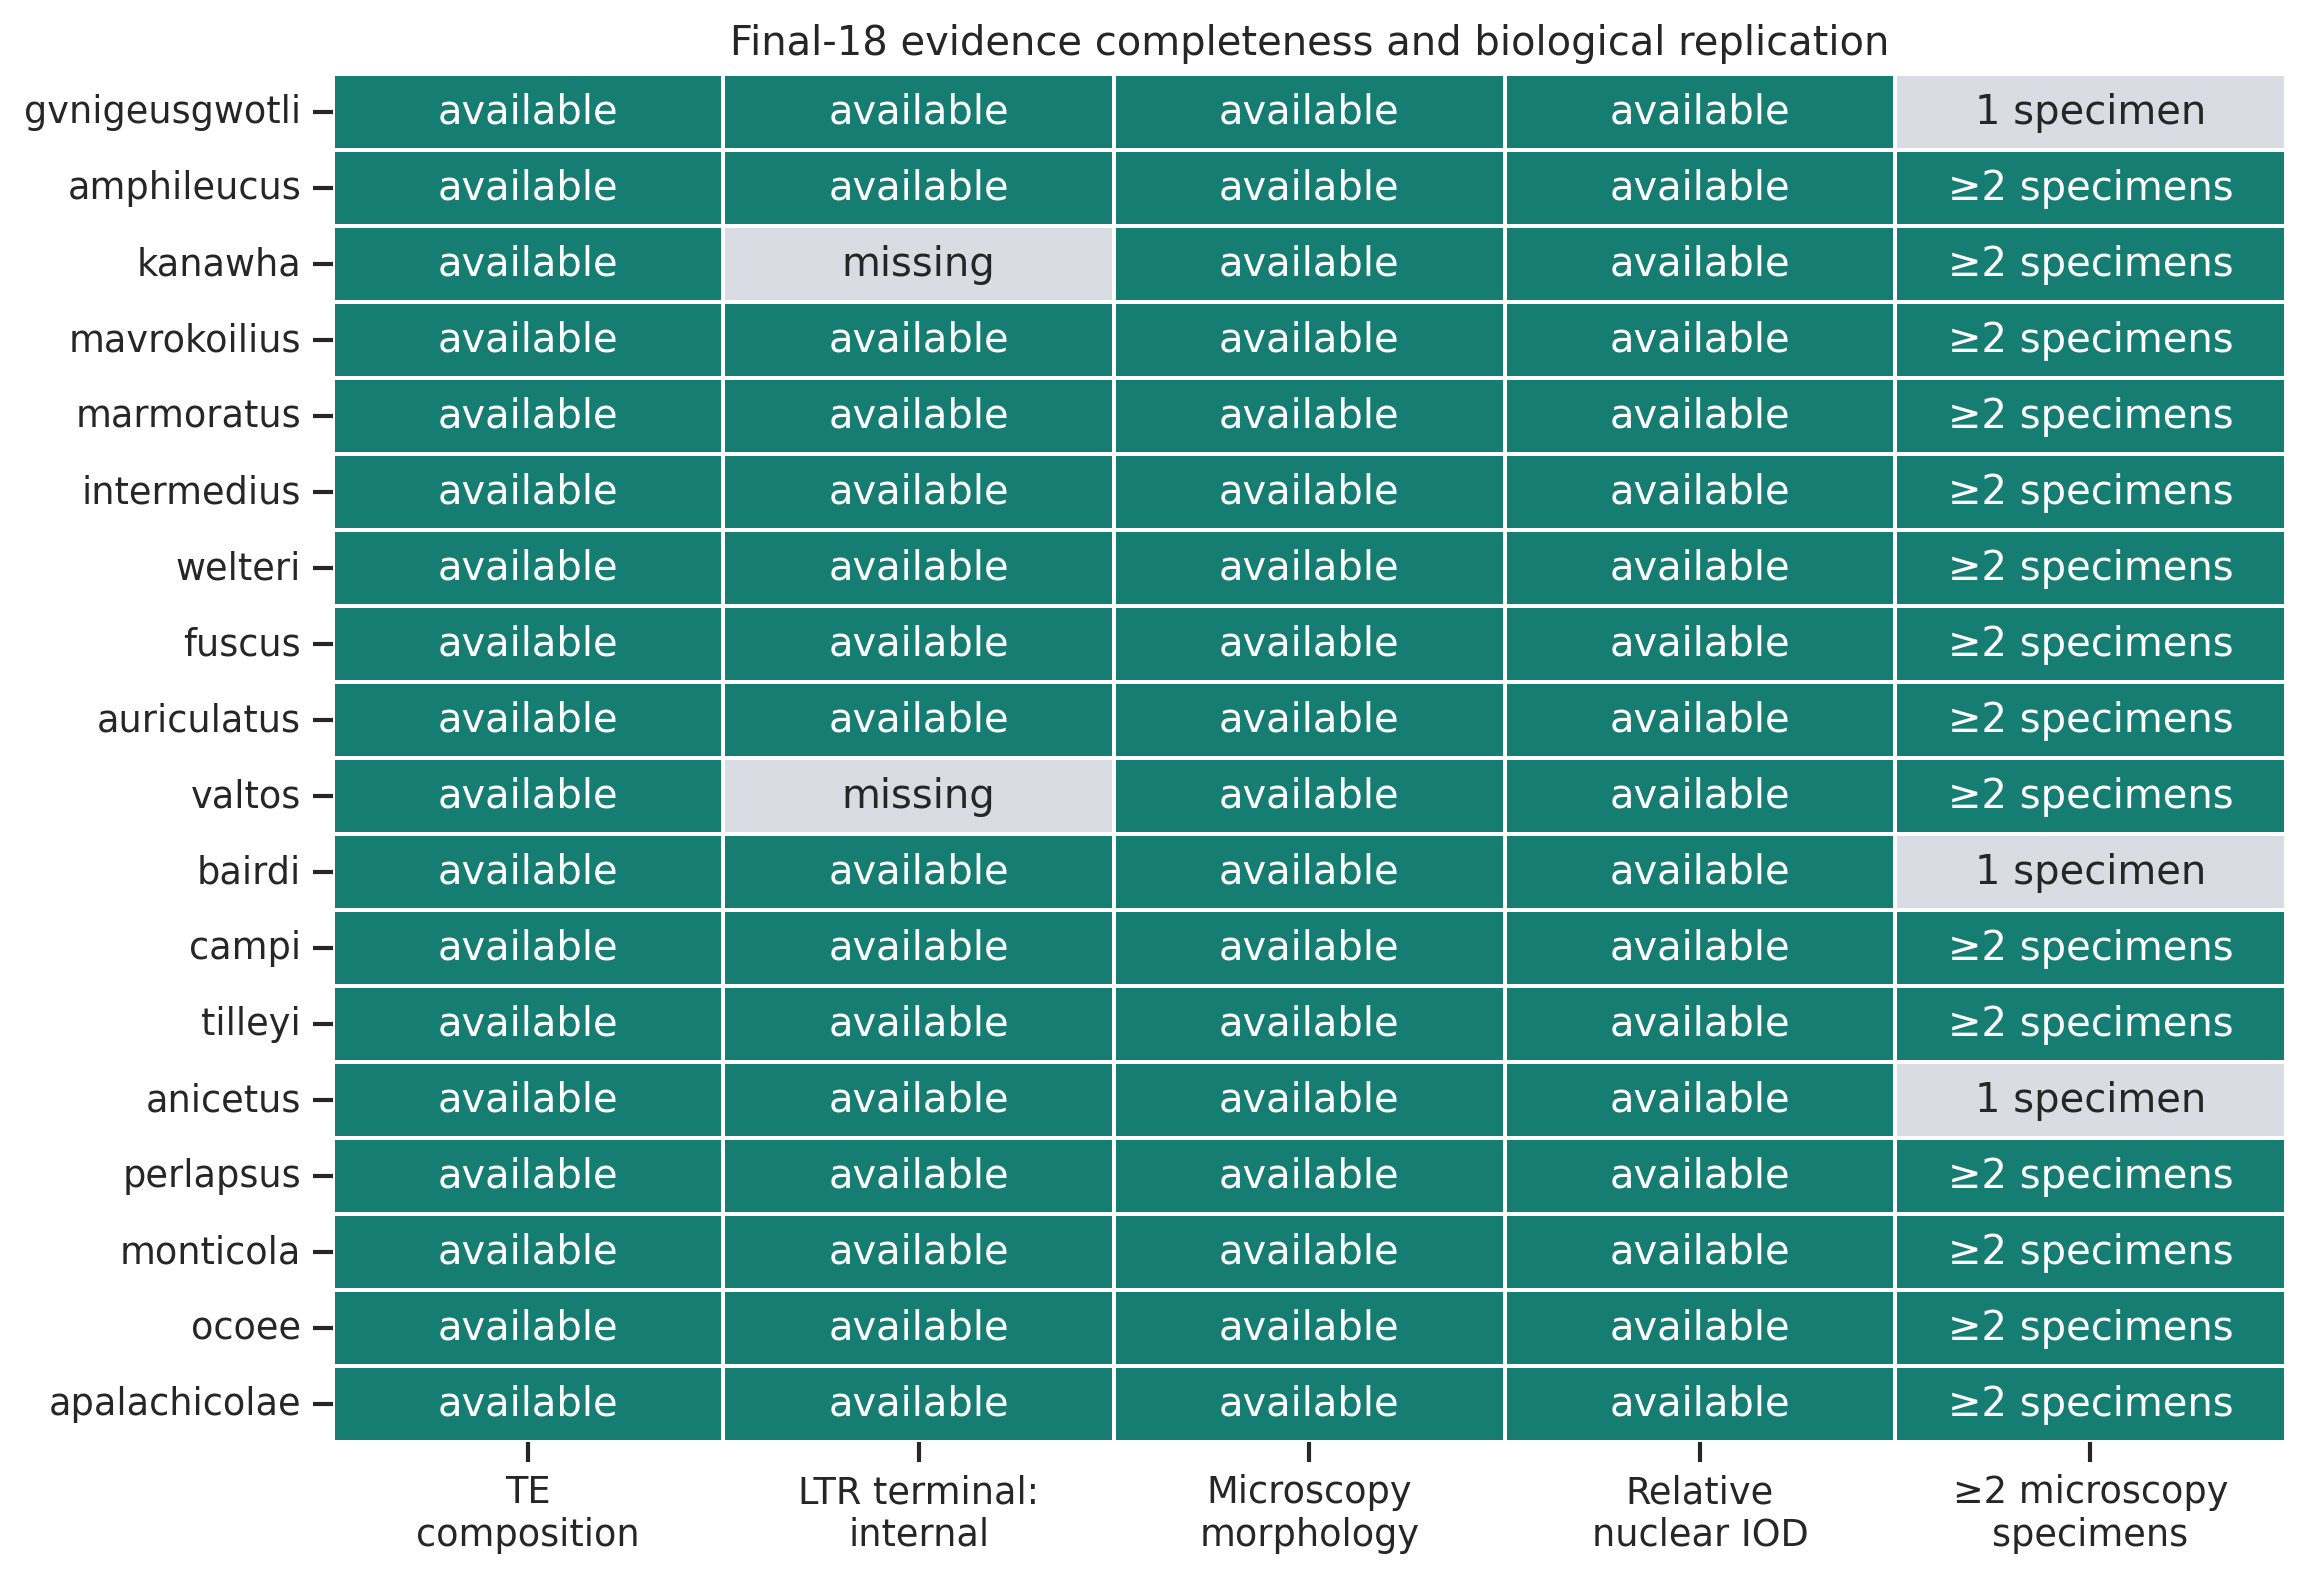

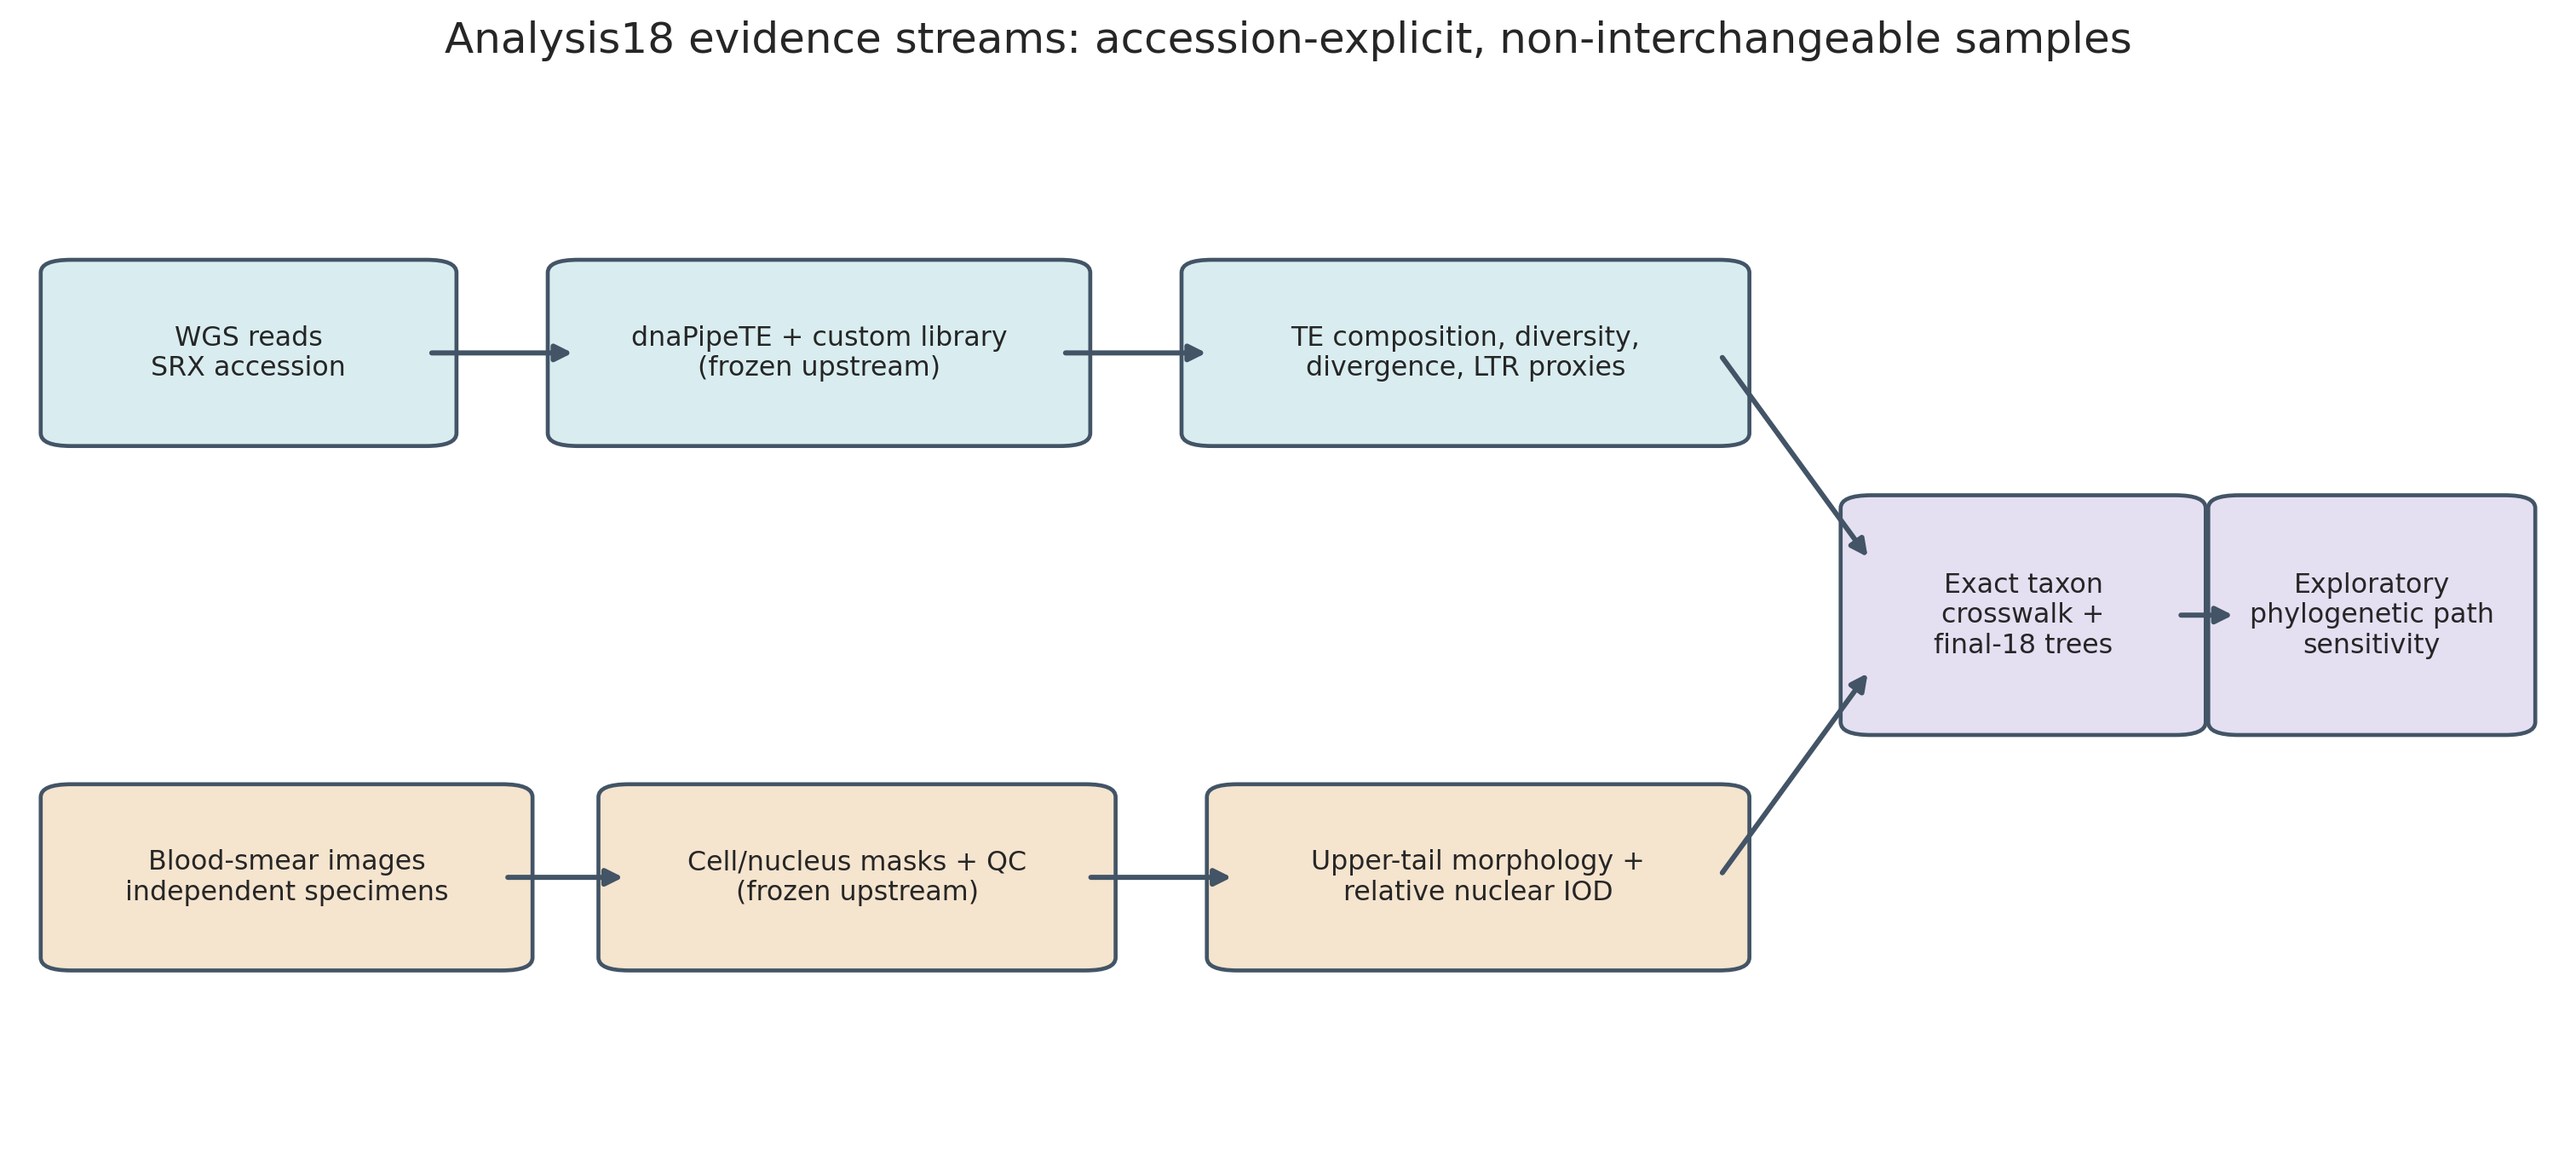

In [6]:
registry = read_csv("path_analysis/data/derived/source_file_registry.csv")
gates = read_csv("results/data/corrected/path_analysis/publication_release_gate_matrix_analysis18_v1.csv")
current_registry = registry[
    registry.source_id.ne("repo_ectopic_recombination_filtered_3000bp_5plusdomains")
].copy()
display(current_registry[[c for c in ["source_id", "local_path", "sha256", "exists", "origin"] if c in current_registry.columns]])
display(gates[["component", "status", "evidence", "permitted_language"]])
show_figure("results/figures/presentation_notebooks/data_tables/final18_evidence_completeness_analysis18_v1.png")
show_figure("results/figures/presentation_notebooks/data_tables/analysis18_pipeline_evidence_streams_v1.png")

In [7]:
source_files = pd.DataFrame([{'role': 'panel contract', 'path': 'path_analysis/STUDY_SPECIES_PANELS.md'}, {'role': 'panel builder', 'path': 'scripts/processing/build_study_species_panels.py'}, {'role': 'retry-averaged TE34 builder', 'path': 'scripts/processing/build_te34_replicate_averaged_bundle.py'}, {'role': 'source manifest', 'path': 'path_analysis/data/templates/source_manifest.csv'}])
source_files["resolved_path"] = source_files.path.map(lambda value: str(resolve_artifact(value).relative_to(ROOT)))
source_files["exists"] = source_files.path.map(lambda value: resolve_artifact(value).exists())
display(source_files)
if not source_files.exists.all():
    raise FileNotFoundError(source_files.loc[~source_files.exists, "path"].tolist())

,role,path,resolved_path,exists
0,panel contract,path_analysis/STUDY_SPECIES_PANELS.md,path_analysis/STUDY_SPECIES_PANELS.md,True
1,panel builder,scripts/processing/build_study_species_panels.py,scripts/processing/build_study_species_panels.py,True
2,retry-averaged TE34 builder,scripts/processing/build_te34_replicate_averaged_bundle.py,scripts/processing/build_te34_replicate_averaged_bundle.py,True
3,source manifest,path_analysis/data/templates/source_manifest.csv,results/data/research_review/frozen_inputs/path_analysis/data/templates/source_manifest.csv,True


## Review boundary

Do not shrink TE34 or Cell21 to the path18 overlap for descriptive figures. Do
not combine retry outputs as extra species. Do not restore *planiceps* as a row;
the current expert-reidentified *fuscus* comparative resource is accession-explicit
in the panel, and the separate chromosome-level validation assembly is not silently
substituted for it.